In [105]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [106]:
import zipfile

zip_path = "/content/drive/MyDrive/contest_release.zip"

with zipfile.ZipFile(zip_path) as z:
    all_items = z.namelist()
    infos = z.infolist()

# Separate folders and files
folders = [f for f in all_items if f.endswith("/")]
files   = [f for f in all_items if not f.endswith("/")]

print(f"📁 Folders ({len(folders)}):")
for folder in sorted(folders):
    print(f"   {folder}")

print(f"\n📄 Files ({len(files)}):")
for file in sorted(files):
    size = next(i.file_size for i in infos if i.filename == file)
    print(f"   {file}  ({size:,} bytes)")

📁 Folders (350):
   dataset1/
   dataset1/Car_video/
   dataset1/Car_video_2/
   dataset1/Car_video_3/
   dataset1/Car_video_4/
   dataset1/basketball/
   dataset1/basketball_2/
   dataset1/basketball_3/
   dataset1/cows/
   dataset1/horse_4/
   dataset1/horse_6/
   dataset1/motorcycle/
   dataset1/person_3/
   dataset1/person_4/
   dataset1/plane/
   dataset1/sheeps/
   dataset1/sheeps_2/
   dataset1/surfer/
   dataset1/surfer_1/
   dataset1/volleyball/
   dataset2/
   dataset2/Animal1/
   dataset2/Animal2/
   dataset2/Animal3/
   dataset2/Animal4/
   dataset2/BMX2/
   dataset2/BMX3/
   dataset2/BMX4/
   dataset2/BMX5/
   dataset2/Basketball/
   dataset2/Car2/
   dataset2/Car4/
   dataset2/Car5/
   dataset2/Car6/
   dataset2/Car8/
   dataset2/ChasingDrones/
   dataset2/Girl1/
   dataset2/Girl2/
   dataset2/Gull1/
   dataset2/Gull2/
   dataset2/Horse1/
   dataset2/Horse2/
   dataset2/Kiting/
   dataset2/ManRunning1/
   dataset2/ManRunning2/
   dataset2/Motor1/
   dataset2/Motor2/
   da

In [107]:
import zipfile
import json
import pandas as pd
import io

zip_path = "/content/drive/MyDrive/contest_release.zip"

with zipfile.ZipFile(zip_path) as z:
    # Load JSON
    with z.open("metadata/contestant_manifest.json") as f:
        manifest = json.load(f)

    # Load CSV
    with z.open("metadata/sample_submission.csv") as f:
        submission_df = pd.read_csv(f)

In [108]:
# ── Manifest EDA ──────────────────────────────────────────────
print("=== MANIFEST ===")
print(f"Type: {type(manifest)}")

if isinstance(manifest, dict):
    print(f"Top-level keys: {list(manifest.keys())}")
    for k, v in manifest.items():
        print(f"  '{k}': {type(v).__name__}  →  {str(v)[:120]}")

elif isinstance(manifest, list):
    print(f"Number of entries: {len(manifest)}")
    print(f"\nFirst entry:\n{json.dumps(manifest[0], indent=2)}")
    print(f"\nKeys in each entry: {list(manifest[0].keys())}")

=== MANIFEST ===
Type: <class 'dict'>
Top-level keys: ['train', 'public_lb']
  'train': dict  →  {'dataset1/Car_video_2': {'dataset': 'dataset1', 'seq_name': 'Car_video_2', 'n_frames': 678, 'native_fps': 60, 'video_pa
  'public_lb': dict  →  {'dataset1/Car_video': {'dataset': 'dataset1', 'seq_name': 'Car_video', 'n_frames': 585, 'native_fps': 60, 'video_path':


In [109]:
# ── Manifest Deep Dive ────────────────────────────────────────

# 1. How many sequences in each split?
print(f"Train sequences:     {len(manifest['train'])}")
print(f"Public LB sequences: {len(manifest['public_lb'])}")

# 2. Inspect one full entry from each split
first_train_key = list(manifest['train'].keys())[0]
first_lb_key    = list(manifest['public_lb'].keys())[0]

print(f"\n=== Sample TRAIN entry: '{first_train_key}' ===")
print(json.dumps(manifest['train'][first_train_key], indent=2))

print(f"\n=== Sample PUBLIC_LB entry: '{first_lb_key}' ===")
print(json.dumps(manifest['public_lb'][first_lb_key], indent=2))

Train sequences:     255
Public LB sequences: 89

=== Sample TRAIN entry: 'dataset1/Car_video_2' ===
{
  "dataset": "dataset1",
  "seq_name": "Car_video_2",
  "n_frames": 678,
  "native_fps": 60,
  "video_path": "dataset1/Car_video_2/Car_video_2.mp4",
  "annotation_path": "dataset1/Car_video_2/annotation.txt"
}

=== Sample PUBLIC_LB entry: 'dataset1/Car_video' ===
{
  "dataset": "dataset1",
  "seq_name": "Car_video",
  "n_frames": 585,
  "native_fps": 60,
  "video_path": "dataset1/Car_video/Car_video.mp4",
  "annotation_path": "dataset1/Car_video/annotation.txt"
}


In [110]:
# 3. Summary stats across all train sequences
import pandas as pd

train_df = pd.DataFrame(manifest['train']).T.reset_index(drop=True)
lb_df    = pd.DataFrame(manifest['public_lb']).T.reset_index(drop=True)

print("=== TRAIN - All Columns ===")
print(train_df.dtypes)
print(train_df.head(3))

print("\n=== TRAIN - Numeric Stats ===")
print(train_df.describe())

=== TRAIN - All Columns ===
dataset            object
seq_name           object
n_frames           object
native_fps         object
video_path         object
annotation_path    object
dtype: object
    dataset     seq_name n_frames native_fps  \
0  dataset1  Car_video_2      678         60   
1  dataset1  Car_video_3      223         24   
2  dataset1      horse_4      235         25   

                             video_path                      annotation_path  
0  dataset1/Car_video_2/Car_video_2.mp4  dataset1/Car_video_2/annotation.txt  
1  dataset1/Car_video_3/Car_video_3.mp4  dataset1/Car_video_3/annotation.txt  
2          dataset1/horse_4/horse_4.mp4      dataset1/horse_4/annotation.txt  

=== TRAIN - Numeric Stats ===
         dataset seq_name  n_frames  native_fps  \
count        255      255       255         255   
unique         5      229       228           6   
top     dataset5     car3       109          30   
freq          94        3         3         119   

      

In [111]:
# 4. Unique datasets and FPS distributions
print("Datasets in train:", train_df['dataset'].value_counts().to_dict())
print("FPS values in train:", train_df['native_fps'].value_counts().to_dict())

print("\nDatasets in public_lb:", lb_df['dataset'].value_counts().to_dict())
print("FPS values in public_lb:", lb_df['native_fps'].value_counts().to_dict())

Datasets in train: {'dataset5': 94, 'dataset3': 84, 'dataset2': 53, 'dataset4': 15, 'dataset1': 9}
FPS values in train: {30: 119, 24: 80, 96: 52, 60: 2, 25: 1, 50: 1}

Datasets in public_lb: {'dataset5': 29, 'dataset3': 28, 'dataset2': 17, 'dataset1': 10, 'dataset4': 5}
FPS values in public_lb: {30: 41, 24: 28, 96: 17, 60: 2, 25: 1}


In [112]:
# 1. Check ALL top-level keys in manifest (confirm no hidden splits)
print("All manifest keys:", list(manifest.keys()))

# 2. Check the annotation files — do public_lb sequences have annotations?
#    If annotation is empty/missing → public_lb IS the test set
with zipfile.ZipFile(zip_path) as z:
    lb_keys = list(manifest['public_lb'].keys())

    for key in lb_keys[:5]:  # check first 5
        ann_path = manifest['public_lb'][key]['annotation_path']
        with z.open(ann_path) as f:
            content = f.read()
        print(f"{key}: annotation size = {len(content)} bytes → {'HAS LABELS' if len(content) > 50 else '⚠️ EMPTY/MINIMAL'}")

All manifest keys: ['train', 'public_lb']
dataset1/Car_video: annotation size = 16 bytes → ⚠️ EMPTY/MINIMAL
dataset1/Car_video_4: annotation size = 13 bytes → ⚠️ EMPTY/MINIMAL
dataset1/basketball: annotation size = 14 bytes → ⚠️ EMPTY/MINIMAL
dataset1/basketball_2: annotation size = 15 bytes → ⚠️ EMPTY/MINIMAL
dataset1/basketball_3: annotation size = 14 bytes → ⚠️ EMPTY/MINIMAL


In [113]:
import zipfile

zip_path = "/content/drive/MyDrive/contest_release.zip"

# Open ZIP once, read all annotations in one pass
with zipfile.ZipFile(zip_path) as z:
    # Build a lookup: filename → file size (from ZIP index, NO reading needed)
    size_lookup = {info.filename: info.file_size for info in z.infolist()}

# Now just look up sizes instantly — no file reading at all!
train_ann_sizes = [
    size_lookup[val['annotation_path']]
    for val in manifest['train'].values()
]

lb_ann_sizes = [
    size_lookup[val['annotation_path']]
    for val in manifest['public_lb'].values()
]

print(f"Train    — avg: {sum(train_ann_sizes)/len(train_ann_sizes):.0f} bytes  |  min: {min(train_ann_sizes)}  |  max: {max(train_ann_sizes)}")
print(f"Public LB — avg: {sum(lb_ann_sizes)/len(lb_ann_sizes):.0f} bytes  |  min: {min(lb_ann_sizes)}  |  max: {max(lb_ann_sizes)}")

print(f"\nTrain     empty (<50 bytes): {sum(1 for s in train_ann_sizes if s < 50)}")
print(f"Public LB empty (<50 bytes): {sum(1 for s in lb_ann_sizes if s < 50)}")

Train    — avg: 20141 bytes  |  min: 1147  |  max: 109247
Public LB — avg: 21 bytes  |  min: 12  |  max: 43

Train     empty (<50 bytes): 0
Public LB empty (<50 bytes): 89


In [114]:
# Peek at a few public_lb annotation files to see what's inside
with zipfile.ZipFile(zip_path) as z:
    for key in list(manifest['public_lb'].keys())[:5]:
        ann_path = manifest['public_lb'][key]['annotation_path']
        with z.open(ann_path) as f:
            content = f.read().decode('utf-8')
        print(f"{key}: '{repr(content)}'")

dataset1/Car_video: ''536,551,226,142\n''
dataset1/Car_video_4: ''73,447,12,21\n''
dataset1/basketball: ''625,381,73,57\n''
dataset1/basketball_2: ''2292,761,71,64\n''
dataset1/basketball_3: ''1327,91,33,33\n''


In [115]:
# ── Submission CSV EDA ────────────────────────────────────────
print("=== SAMPLE SUBMISSION CSV ===")
print(f"Shape: {submission_df.shape}")
print(f"\nColumns: {list(submission_df.columns)}")
print(f"\nDtypes:\n{submission_df.dtypes}")
print(f"\nFirst 5 rows:\n{submission_df.head()}")
print(f"\nNull counts:\n{submission_df.isnull().sum()}")
print(f"\nBasic stats:\n{submission_df.describe()}")

=== SAMPLE SUBMISSION CSV ===
Shape: (74293, 5)

Columns: ['id', 'x', 'y', 'w', 'h']

Dtypes:
id    object
x      int64
y      int64
w      int64
h      int64
dtype: object

First 5 rows:
                     id  x  y  w  h
0  dataset1/Car_video_0  0  0  0  0
1  dataset1/Car_video_1  0  0  0  0
2  dataset1/Car_video_2  0  0  0  0
3  dataset1/Car_video_3  0  0  0  0
4  dataset1/Car_video_4  0  0  0  0

Null counts:
id    0
x     0
y     0
w     0
h     0
dtype: int64

Basic stats:
             x        y        w        h
count  74293.0  74293.0  74293.0  74293.0
mean       0.0      0.0      0.0      0.0
std        0.0      0.0      0.0      0.0
min        0.0      0.0      0.0      0.0
25%        0.0      0.0      0.0      0.0
50%        0.0      0.0      0.0      0.0
75%        0.0      0.0      0.0      0.0
max        0.0      0.0      0.0      0.0


In [116]:
# Decode the id format: "dataset1/Car_video_0" → seq_name + frame_index
print("=== ID FORMAT ANALYSIS ===")
print(submission_df['id'].head(20).tolist())

# Split id into seq and frame
submission_df[['seq_id', 'frame_idx']] = submission_df['id'].str.rsplit('_', n=1, expand=True)
submission_df['frame_idx'] = submission_df['frame_idx'].astype(int)

print(f"\nUnique sequences: {submission_df['seq_id'].nunique()}")
print(f"Total frames to predict: {len(submission_df)}")

# Frames per sequence
frames_per_seq = submission_df.groupby('seq_id')['frame_idx'].agg(['count', 'min', 'max'])
print(f"\nFrames per sequence stats:")
print(frames_per_seq.describe())
print(f"\nSample sequences:")
print(frames_per_seq.head(10))

=== ID FORMAT ANALYSIS ===
['dataset1/Car_video_0', 'dataset1/Car_video_1', 'dataset1/Car_video_2', 'dataset1/Car_video_3', 'dataset1/Car_video_4', 'dataset1/Car_video_5', 'dataset1/Car_video_6', 'dataset1/Car_video_7', 'dataset1/Car_video_8', 'dataset1/Car_video_9', 'dataset1/Car_video_10', 'dataset1/Car_video_11', 'dataset1/Car_video_12', 'dataset1/Car_video_13', 'dataset1/Car_video_14', 'dataset1/Car_video_15', 'dataset1/Car_video_16', 'dataset1/Car_video_17', 'dataset1/Car_video_18', 'dataset1/Car_video_19']

Unique sequences: 89
Total frames to predict: 74293

Frames per sequence stats:
             count   min          max
count    89.000000  89.0    89.000000
mean    834.752809   0.0   833.752809
std     743.686201   0.0   743.686201
min      20.000000   0.0    19.000000
25%     240.000000   0.0   239.000000
50%     630.000000   0.0   629.000000
75%    1243.000000   0.0  1242.000000
max    4357.000000   0.0  4356.000000

Sample sequences:
                       count  min  max
s

In [117]:
# Cross-check: do seq_ids match public_lb manifest keys?
submission_seqs = set(submission_df['seq_id'].unique())
manifest_lb_seqs = set(manifest['public_lb'].keys())

print(f"Submission unique seqs:  {len(submission_seqs)}")
print(f"Manifest public_lb seqs: {len(manifest_lb_seqs)}")
print(f"In both:      {len(submission_seqs & manifest_lb_seqs)}")
print(f"In sub only:  {submission_seqs - manifest_lb_seqs}")
print(f"In manifest only: {manifest_lb_seqs - submission_seqs}")

Submission unique seqs:  89
Manifest public_lb seqs: 89
In both:      89
In sub only:  set()
In manifest only: set()


In [118]:
# Verify frame 0 = initial bbox (given), rest = what we must predict
# Frame 0 should match the public_lb annotation exactly
with zipfile.ZipFile(zip_path) as z:
    for key in list(manifest['public_lb'].keys())[:3]:
        ann_path = manifest['public_lb'][key]['annotation_path']
        with z.open(ann_path) as f:
            given_bbox = f.read().decode('utf-8').strip()

        # Get frame 0 from submission
        frame0 = submission_df[submission_df['seq_id'] == key].query('frame_idx == 0')[['x','y','w','h']].values

        print(f"{key}")
        print(f"  annotation (given bbox): {given_bbox}")
        print(f"  submission frame 0:      {frame0}")

dataset1/Car_video
  annotation (given bbox): 536,551,226,142
  submission frame 0:      [[0 0 0 0]]
dataset1/Car_video_4
  annotation (given bbox): 73,447,12,21
  submission frame 0:      [[0 0 0 0]]
dataset1/basketball
  annotation (given bbox): 625,381,73,57
  submission frame 0:      [[0 0 0 0]]


In [119]:
import zipfile

zip_path = "/content/drive/MyDrive/contest_release.zip"

with zipfile.ZipFile(zip_path) as z:
    files = z.namelist()

videos = [f for f in files if f.endswith(".mp4")]
annots = [f for f in files if f.endswith("annotation.txt")]

print("Number of videos:", len(videos))
print("Number of annotation files:", len(annots))

Number of videos: 344
Number of annotation files: 344


In [120]:
import zipfile
import cv2

target_video = "dataset1/Car_video_2/Car_video_2.mp4"

with zipfile.ZipFile(zip_path) as z:
    z.extract(target_video, "/content/")

video_path = "/content/" + target_video

cap = cv2.VideoCapture(video_path)

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("Frames:", frame_count)
print("FPS:", fps)
print("Resolution:", width, "x", height)

cap.release()

Frames: 678
FPS: 60.017704337562705
Resolution: 778 x 1168


In [121]:
target_annot = "dataset1/Car_video_2/annotation.txt"

with zipfile.ZipFile(zip_path) as z:
    z.extract(target_annot, "/content/")

annot_path = "/content/" + target_annot

with open(annot_path, "r") as f:
    lines = f.readlines()

print("Number of annotations:", len(lines))
print(lines[:5])

Number of annotations: 678
['383,545,156,74\n', '387,546,156,74\n', '388,545,156,75\n', '391,545,156,75\n', '391,545,156,75\n']


In [122]:
import pandas as pd

data = []

for i, line in enumerate(lines):
    parts = line.strip().split(",")
    x, y, w, h = map(float, parts)

    data.append([i, x, y, w, h])  # i = frame number

df = pd.DataFrame(data, columns=["frame", "x", "y", "w", "h"])

df.head()

,frame,x,y,w,h
0,0,383.0,545.0,156.0,74.0
1,1,387.0,546.0,156.0,74.0
2,2,388.0,545.0,156.0,75.0
3,3,391.0,545.0,156.0,75.0
4,4,391.0,545.0,156.0,75.0


In [123]:
import os

extract_dir = "/content/annotations_only/"
sentinel = os.path.join(extract_dir, ".extracted")

if not os.path.exists(sentinel):
    import zipfile
    zip_path = "/content/drive/MyDrive/contest_release.zip"
    os.makedirs(extract_dir, exist_ok=True)

    with zipfile.ZipFile(zip_path) as z:
        txt_files = [f for f in z.namelist() if f.endswith('.txt')
                                              or f.endswith('.json')
                                              or f.endswith('.csv')]
        for f in txt_files:
            z.extract(f, extract_dir)

    open(sentinel, 'w').close()  # mark as done
    print("✅ Extraction complete.")
else:
    print("✅ Already extracted — skipping.")

✅ Already extracted — skipping.


In [124]:
import json
import pandas as pd
import numpy as np

with open(f"{extract_dir}metadata/contestant_manifest.json") as f:
    manifest = json.load(f)

submission_df = pd.read_csv(f"{extract_dir}metadata/sample_submission.csv")
submission_df[['seq_id', 'frame_idx']] = submission_df['id'].str.rsplit('_', n=1, expand=True)
submission_df['frame_idx'] = submission_df['frame_idx'].astype(int)

print(f"Train sequences:     {len(manifest['train'])}")
print(f"Public LB sequences: {len(manifest['public_lb'])}")
print(f"Submission rows:     {len(submission_df):,}")

Train sequences:     255
Public LB sequences: 89
Submission rows:     74,293


In [125]:
records = []

for key, val in manifest['train'].items():
    ann_path = os.path.join(extract_dir, val['annotation_path'])

    with open(ann_path) as f:
        lines = f.read().strip().split('\n')

    for frame_idx, line in enumerate(lines):
        line = line.strip()

        # Explicit missing detection — keep the row, just mark it missing
        is_missing = line in ('', 'NaN', 'nan', '0,0,0,0')

        try:
            if is_missing:
                raise ValueError("missing")
            x, y, w, h = map(float, line.split(','))
            if x == 0 and y == 0 and w == 0 and h == 0:
                raise ValueError("zero bbox")
            records.append({
                'seq_key': key, 'dataset': val['dataset'],
                'seq_name': val['seq_name'],
                'n_frames': int(val['n_frames']),
                'native_fps': int(val['native_fps']),
                'frame_idx': frame_idx,   # ← always the TRUE line position
                'x': x, 'y': y, 'w': w, 'h': h,
                'area': w * h,
                'aspect_ratio': w / h if h > 0 else np.nan,
                'cx': x + w/2, 'cy': y + h/2,
                'missing': False,
            })
        except:
            records.append({
                'seq_key': key, 'dataset': val['dataset'],
                'seq_name': val['seq_name'],
                'n_frames': int(val['n_frames']),
                'native_fps': int(val['native_fps']),
                'frame_idx': frame_idx,   # ← still recorded, just NaN values
                'x': np.nan, 'y': np.nan, 'w': np.nan, 'h': np.nan,
                'area': np.nan, 'aspect_ratio': np.nan,
                'cx': np.nan, 'cy': np.nan,
                'missing': True,
            })

df = pd.DataFrame(records)
print(f"Total frame records : {len(df):,}")
print(f"Sequences           : {df['seq_key'].nunique()}")
print(f"Missing frames      : {df['missing'].sum():,}  ({df['missing'].mean()*100:.1f}%)")

Total frame records : 223,002
Sequences           : 255
Missing frames      : 5,323  (2.4%)


In [126]:
# Validate: each sequence should have exactly n_frames records
mismatches = (
    df.groupby('seq_key')
    .apply(lambda g: g['frame_idx'].max() + 1 != g['n_frames'].iloc[0])
)
bad_seqs = mismatches[mismatches].index.tolist()
if bad_seqs:
    print(f"⚠️  Frame count mismatch in {len(bad_seqs)} sequences: {bad_seqs}")
else:
    print("✅ All sequences have consistent frame counts")

✅ All sequences have consistent frame counts


/tmp/ipykernel_3957/818330567.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g['frame_idx'].max() + 1 != g['n_frames'].iloc[0])


In [127]:
# ── Diagnose the mismatch ──────────────────────────────────────────
diag = (
    df.groupby('seq_key')
    .apply(lambda g: pd.Series({
        'actual_lines' : g['frame_idx'].max() + 1,
        'manifest_n'   : g['n_frames'].iloc[0],
        'diff'         : g['n_frames'].iloc[0] - (g['frame_idx'].max() + 1),
    }), include_groups=False)
    .reset_index()
)

bad = diag[diag['diff'] != 0].sort_values('diff', ascending=False)
print(f"Mismatched sequences : {len(bad)}")
print(f"Diff > 0 (txt shorter than manifest) : {(bad['diff'] > 0).sum()}")
print(f"Diff < 0 (txt longer  than manifest) : {(bad['diff'] < 0).sum()}")
print(f"\nTop 10 biggest gaps:")
print(bad.head(10).to_string(index=False))
print(f"\nDiff distribution:\n{bad['diff'].describe()}")

Mismatched sequences : 0
Diff > 0 (txt shorter than manifest) : 0
Diff < 0 (txt longer  than manifest) : 0

Top 10 biggest gaps:
Empty DataFrame
Columns: [seq_key, actual_lines, manifest_n, diff]
Index: []

Diff distribution:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: diff, dtype: float64


In [128]:
summary = (
    df.groupby(['seq_key', 'dataset', 'seq_name', 'n_frames', 'native_fps'])
    .agg(
        total_frames   = ('frame_idx', 'count'),
        missing_frames = ('missing', 'sum'),
    )
    .reset_index()
)

summary['missing_pct'] = (summary['missing_frames'] / summary['n_frames'] * 100).round(1)
summary['has_missing'] = summary['missing_frames'] > 0


print(f"Sequences with missing frames: {summary['has_missing'].sum()} / {len(summary)}")
summary.sort_values('missing_pct', ascending=False)

Sequences with missing frames: 57 / 255


,seq_key,dataset,seq_name,n_frames,native_fps,total_frames,missing_frames,missing_pct,has_missing
166,dataset5/bird1_3,dataset5,bird1_3,865,30,865,392,45.3,True
147,dataset4/bird1,dataset4,bird1,2437,30,2437,1057,43.4,True
107,dataset3/dark_car2-n,dataset3,dark_car2-n,939,30,939,373,39.7,True
131,dataset3/runner2,dataset3,runner2,147,24,147,53,36.1,True
164,dataset5/bird1_1,dataset5,bird1_1,253,30,253,59,23.3,True
...,...,...,...,...,...,...,...,...,...
250,dataset5/wakeboard3,dataset5,wakeboard3,823,96,823,0,0.0,False
251,dataset5/wakeboard4,dataset5,wakeboard4,697,96,697,0,0.0,False
252,dataset5/wakeboard5,dataset5,wakeboard5,1675,96,1675,0,0.0,False
253,dataset5/wakeboard8,dataset5,wakeboard8,1543,96,1543,0,0.0,False


In [129]:
summary[summary['has_missing']].sort_values('missing_pct', ascending=False)

,seq_key,dataset,seq_name,n_frames,native_fps,total_frames,missing_frames,missing_pct,has_missing
166,dataset5/bird1_3,dataset5,bird1_3,865,30,865,392,45.3,True
147,dataset4/bird1,dataset4,bird1,2437,30,2437,1057,43.4,True
107,dataset3/dark_car2-n,dataset3,dark_car2-n,939,30,939,373,39.7,True
131,dataset3/runner2,dataset3,runner2,147,24,147,53,36.1,True
164,dataset5/bird1_1,dataset5,bird1_1,253,30,253,59,23.3,True
178,dataset5/car12,dataset5,car12,499,96,499,105,21.0,True
188,dataset5/car1_3,dataset5,car1_3,1003,96,1003,182,18.1,True
165,dataset5/bird1_2,dataset5,bird1_2,703,30,703,118,16.8,True
212,dataset5/person10,dataset5,person10,1021,30,1021,166,16.3,True
74,dataset3/bike4_1,dataset3,bike4_1,686,30,686,93,13.6,True


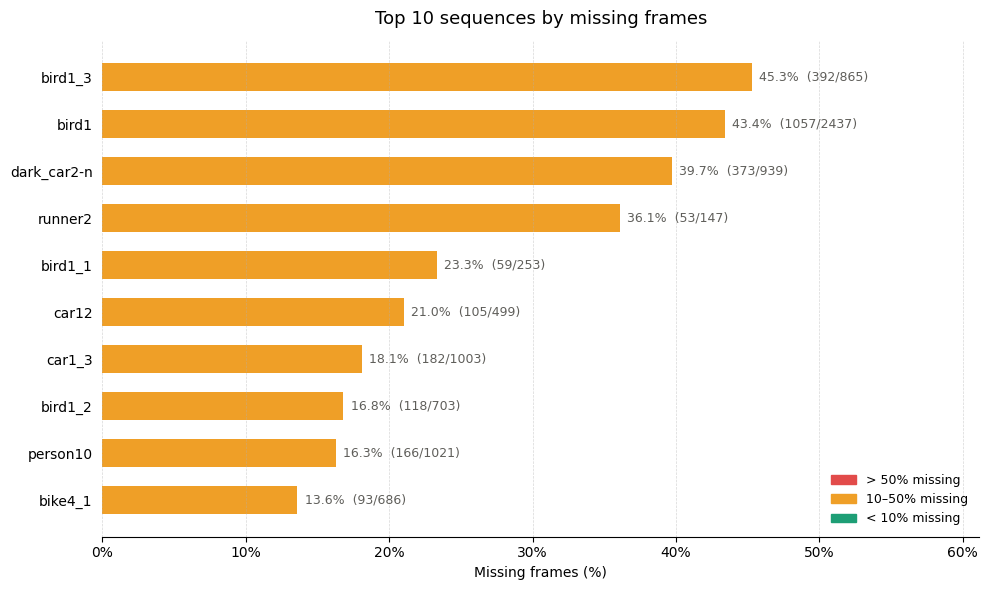

In [130]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

top10 = (
    summary[summary['has_missing']]
    .sort_values('missing_pct', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#E24B4A' if p > 50 else '#EF9F27' if p > 10 else '#1D9E75'
          for p in top10['missing_pct']]

bars = ax.barh(
    top10['seq_name'],
    top10['missing_pct'],
    color=colors,
    height=0.6,
    edgecolor='none'
)

# value labels
for bar, (_, row) in zip(bars, top10.iterrows()):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{row['missing_pct']:.1f}%  ({int(row['missing_frames'])}/{int(row['n_frames'])})",
        va='center', ha='left', fontsize=9, color='#5F5E5A'
    )

ax.set_xlim(0, min(top10['missing_pct'].max() * 1.35, 105))
ax.set_xlabel('Missing frames (%)', fontsize=10)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(left=False)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.5)

legend = [
    mpatches.Patch(color='#E24B4A', label='> 50% missing'),
    mpatches.Patch(color='#EF9F27', label='10–50% missing'),
    mpatches.Patch(color='#1D9E75', label='< 10% missing'),
]
ax.legend(handles=legend, fontsize=9, frameon=False, loc='lower right')

ax.set_title('Top 10 sequences by missing frames', fontsize=13, fontweight='normal', pad=12)
plt.tight_layout()
plt.show()

In [131]:
seq_df = df.groupby(['seq_key','dataset','seq_name','n_frames','native_fps']).agg(
    missing_frames = ('missing', 'sum'),
    avg_w          = ('w', 'mean'),
    avg_h          = ('h', 'mean'),
    avg_area       = ('area', 'mean'),
    std_area       = ('area', 'std'),
    avg_aspect     = ('aspect_ratio', 'mean'),
    cx_std         = ('cx', 'std'),
    cy_std         = ('cy', 'std'),
).reset_index()

seq_df['motion_score'] = np.sqrt(seq_df['cx_std']**2 + seq_df['cy_std']**2)
seq_df['size_change']  = seq_df['std_area'] / (seq_df['avg_area'] + 1e-6)
seq_df['missing_pct']  = seq_df['missing_frames'] / seq_df['n_frames'] * 100

print(seq_df[['seq_name','dataset','n_frames','missing_pct',
              'avg_area','motion_score','size_change']].head(10))

      seq_name   dataset  n_frames  missing_pct      avg_area  motion_score  \
0  Car_video_2  dataset1       678     0.000000  87230.123894     55.096972   
1  Car_video_3  dataset1       223     0.000000   7600.551570    133.510131   
2      horse_4  dataset1       235     0.000000  27091.727660    169.294950   
3      horse_6  dataset1       448     0.000000   5393.020089     38.471332   
4   motorcycle  dataset1       801     4.244694   4544.531943    159.945868   
5     person_4  dataset1       602     0.000000   1813.018272    211.807243   
6        plane  dataset1       358     0.000000  11591.648045     80.026317   
7       surfer  dataset1       150     0.000000    798.546667    294.006116   
8   volleyball  dataset1      2088     0.000000  11533.033046    292.487897   
9      Animal1  dataset2       147     0.000000   2050.965986    208.460407   

   size_change  
0     0.389363  
1     0.063286  
2     0.414649  
3     0.323001  
4     1.154013  
5     0.287775  
6     1.275

## EDA — Training Data Overview

---

### Top Row

---

#### 1. Sequences per Dataset

| Dataset | Sequence Count |
|---------|---------------|
| dataset5 | 94 |
| dataset3 | 84 |
| dataset2 | 53 |
| dataset4 | 15 |
| dataset1 | 9 |

**Key observations:**
- dataset5 dominates with 94 sequences, followed closely by dataset3 with 84
- dataset1 is the smallest source with only 9 sequences
- The training set is significantly imbalanced across sources
- This imbalance could bias the model toward dataset5 and dataset3 patterns during training
- dataset4 and dataset1 are underrepresented and may need oversampling or weighted loss to compensate

---

#### 2. Total Frames per Dataset

| Dataset | Total Frames |
|---------|-------------|
| dataset1 | 5,583 |
| dataset2 | 11,834 |
| dataset3 | 75,234 |
| dataset4 | 45,003 |
| dataset5 | 85,348 |

**Key observations:**
- dataset5 leads in raw frame count with 85,348 frames
- dataset3 and dataset4 also contribute heavily at 75,234 and 45,003 frames respectively
- dataset1 has only 9 sequences yet contributes 5,583 frames — meaning its sequences are relatively long on average compared to other datasets
- dataset2 is low in both sequence count and total frames, making it the least represented source overall
- Frame-level imbalance is even more pronounced than sequence-level imbalance

---

#### 3. FPS Distribution

| FPS | Approximate Sequence Count |
|-----|--------------------------|
| 24 | ~80 |
| 25 | ~5 |
| 30 | ~120 |
| 40 | ~2 |
| 60 | ~2 |
| 96 | ~50 |

**Key observations:**
- The vast majority of sequences run at 30 FPS (~120 sequences), making it the dominant frame rate
- 24 FPS is the second most common at ~80 sequences
- A smaller group runs at 96 FPS (~50 sequences)
- Outliers at 25, 40, and 60 FPS exist but are minimal
- The presence of 60 and 96 FPS sequences may require temporal resampling if the model expects a fixed frame rate
- Mixed FPS could affect motion score consistency across datasets since displacement per frame varies with frame rate

---

### Bottom Row

---

#### 4. Sequence Length Distribution

- **Median sequence length:** 661 frames
- **Range:** approximately 0 to 5,000+ frames

**Key observations:**
- The distribution is heavily right-skewed — most sequences are short, under 1,000 frames
- The peak of the histogram is in the 0–200 frame bin with ~58 sequences
- A long tail extends beyond 5,000 frames, meaning a small number of very long sequences exist
- If training samples frames uniformly, these long sequences will be over-represented and could dominate gradient updates
- Recommended approach: sample by sequence first, then sample frames within each sequence, to avoid length bias
- The large gap between the median (661) and the tail suggests the dataset contains two informal tiers — short event clips and long continuous recordings

---

#### 5. Object Size (log avg area)

- **X axis:** log(avg bbox area) per sequence
- **Range:** approximately log(5) to log(11)
- **Peak:** around log(7.5) to log(8)

**Key observations:**
- The distribution is roughly bell-shaped with a slight right skew
- The peak around log(7.5–8) corresponds to medium-sized objects in pixel area
- The wide spread from log(5) to log(11) means the dataset contains objects ranging from very small to very large
- This multi-scale nature requires the model to be robust to significant size variation
- Data augmentation strategies such as random crop, resize, and multi-scale training are strongly recommended
- Sequences at the extremes (log < 6 or log > 10) represent edge cases where detection and tracking are typically harder

---

#### 6. Motion Score Distribution

- **Median motion score:** 160 px
- **Range:** approximately 0 to 400+ px

**Key observations:**
- The distribution is right-skewed — most objects move modestly, with the bulk of sequences falling below 200 px
- The median of 160 px indicates moderate motion is the norm across the dataset
- A long tail extends past 400 px, indicating a meaningful subset of fast-moving targets
- High motion scores correlate with harder tracking cases, more missing annotations, and higher risk of tracker failure
- The motion score is also FPS-dependent — sequences at 96 FPS will naturally show higher per-frame displacement for the same real-world speed
- Sequences above 300 px motion score should be flagged as a hard evaluation subset

---

### Overall Takeaways

- **Dataset imbalance** — dataset5 and dataset3 dominate both by sequence count and frame count; consider weighted sampling or stratified splits to prevent source bias
- **Frame count skew** — sampling uniformly by frame will over-represent long sequences; always sample by sequence first
- **Mixed FPS** — normalize temporal stride or resample to a fixed FPS if the model is time-sensitive or motion-aware
- **Multi-scale objects** — the wide bbox area spread demands strong multi-scale augmentation during training
- **High-motion outliers** — sequences with motion score above 300 px should be isolated into a dedicated hard evaluation set
- **Long-sequence outliers** — sequences beyond 3,000 frames are rare but could disproportionately influence training if not handled carefully

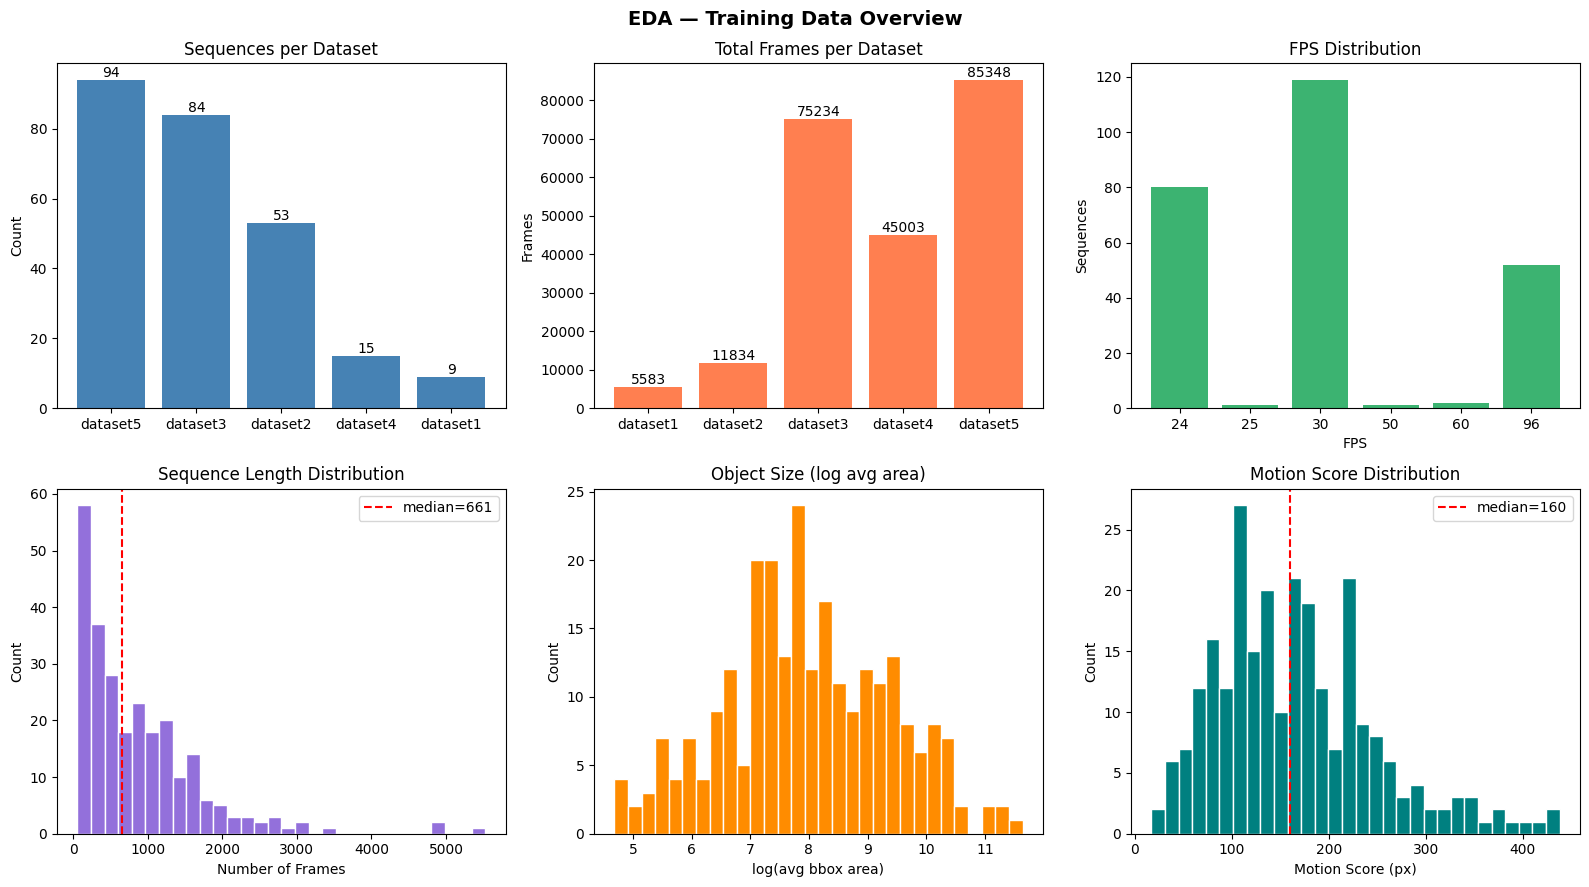

In [132]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('EDA — Training Data Overview', fontsize=14, fontweight='bold')

# Sequences per dataset
ax = axes[0,0]
counts = seq_df['dataset'].value_counts()
bars = ax.bar(counts.index, counts.values, color='steelblue')
ax.bar_label(bars)
ax.set_title('Sequences per Dataset')
ax.set_ylabel('Count')

# Total frames per dataset
ax = axes[0,1]
frames = seq_df.groupby('dataset')['n_frames'].sum()
bars = ax.bar(frames.index, frames.values, color='coral')
ax.bar_label(bars, fmt='%d')
ax.set_title('Total Frames per Dataset')
ax.set_ylabel('Frames')

# FPS distribution
ax = axes[0,2]
fps = seq_df['native_fps'].value_counts().sort_index()
ax.bar(fps.index.astype(str), fps.values, color='mediumseagreen')
ax.set_title('FPS Distribution')
ax.set_xlabel('FPS')
ax.set_ylabel('Sequences')

# Sequence length distribution
ax = axes[1,0]
ax.hist(seq_df['n_frames'], bins=30, color='mediumpurple', edgecolor='white')
ax.axvline(seq_df['n_frames'].median(), color='red', linestyle='--',
           label=f"median={seq_df['n_frames'].median():.0f}")
ax.set_title('Sequence Length Distribution')
ax.set_xlabel('Number of Frames')
ax.set_ylabel('Count')
ax.legend()

# Object size distribution
ax = axes[1,1]
ax.hist(np.log1p(seq_df['avg_area']), bins=30, color='darkorange', edgecolor='white')
ax.set_title('Object Size (log avg area)')
ax.set_xlabel('log(avg bbox area)')
ax.set_ylabel('Count')

# Motion score distribution
ax = axes[1,2]
ax.hist(seq_df['motion_score'], bins=30, color='teal', edgecolor='white')
ax.axvline(seq_df['motion_score'].median(), color='red', linestyle='--',
           label=f"median={seq_df['motion_score'].median():.0f}")
ax.set_title('Motion Score Distribution')
ax.set_xlabel('Motion Score (px)')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.savefig('/content/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Data Quality & Sequence Difficulty

---

### 1. Missing/Occluded Frames per Dataset

| Dataset | Missing Frames | Severity |
|---------|---------------|----------|
| dataset1 | 34 | Low |
| dataset2 | 40 | Low |
| dataset3 | 1,422 | High |
| dataset4 | 1,850 | Very High |
| dataset5 | 1,977 | Very High |

**Key observations:**
- dataset5 and dataset4 are by far the most problematic — 1,977 and 1,850 missing frames respectively
- dataset1 and dataset2 are nearly clean with only 34 and 40 missing frames
- dataset3 sits in the middle at 1,422 missing frames
- The missing frame count strongly correlates with total sequence count (dataset5 had the most sequences overall)
- Even when normalized by sequence count, dataset3–5 carry significantly more occlusion and missing annotation burden
- These three datasets will contribute the most noise during training and should be treated with extra caution

---

### 2. Difficulty Map — Motion vs Size Change (color = sequence length)

Each dot in the scatter plot represents one sequence, plotted along three dimensions:

| Axis / Property | What it measures |
|-----------------|-----------------|
| **X axis** | Motion score (px) — how much the object moves across frames |
| **Y axis** | Size change — std/mean of bbox area — how much the object grows or shrinks |
| **Color** | Sequence length — purple = short, yellow/green = long |

**Key observations:**

- **Most sequences cluster** in the low motion (0–200 px) and low size change (0–0.5) region — these are the easy, stable sequences that a tracker should handle well

- **The hardest sequences** sit in the top-right corner (high motion + high size change simultaneously), and they tend to be **short and purple** — suggesting that the most difficult conditions appear in brief, concentrated bursts rather than long sequences

- **Long sequences (yellow/green)** are mostly concentrated at low-to-medium motion and low size change — long sequences tend to be more stable and predictable, possibly because they are recorded in controlled or less dynamic environments

- **A cluster of outliers** shows very high size change (> 2.0) with relatively low motion score — these are objects that barely move spatially but drastically change in scale, most likely caused by camera zoom, depth change, or the object approaching/receding from the camera

- **High motion alone (> 300 px, low size change)** represents a separate difficulty tier — fast-moving but scale-stable objects, where the tracker needs strong temporal consistency but not scale adaptation

---

### Overall Takeaways

- **Data quality is uneven** — dataset1 and dataset2 are clean; dataset3–5 introduce significant missing frame noise that should be accounted for during training
- **Hardest sequences are short** — brief, fast, scale-varying sequences are the most challenging edge cases in this dataset
- **Long sequences are easier** — stable motion and size make them more predictable, but they may underrepresent real-world difficulty
- **Three distinct difficulty tiers exist:**
  1. Easy — low motion, low size change (majority of data)
  2. Scale-only hard — low motion but high size change (zoom/depth effects)
  3. Fully hard — high motion + high size change (top-right cluster, short sequences)
- **Recommended action** — isolate the top-right cluster (motion > 250 px AND size change > 1.0) as a dedicated hard evaluation subset to stress-test tracker performance on the most challenging cases

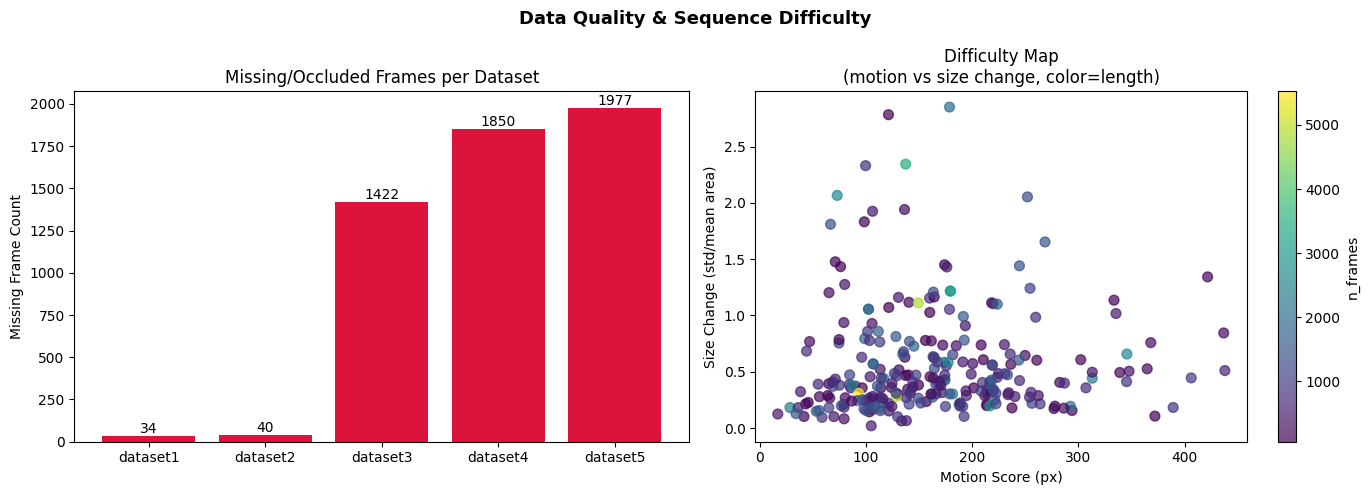

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Data Quality & Sequence Difficulty', fontsize=13, fontweight='bold')

# Missing frames per dataset
ax = axes[0]
miss = seq_df.groupby('dataset')['missing_frames'].sum()
bars = ax.bar(miss.index, miss.values, color='crimson')
ax.bar_label(bars)
ax.set_title('Missing/Occluded Frames per Dataset')
ax.set_ylabel('Missing Frame Count')

# Difficulty scatter: motion vs size change
ax = axes[1]
sc = ax.scatter(seq_df['motion_score'], seq_df['size_change'],
                c=seq_df['n_frames'], cmap='viridis', alpha=0.7, s=50)
plt.colorbar(sc, ax=ax, label='n_frames')
ax.set_title('Difficulty Map\n(motion vs size change, color=length)')
ax.set_xlabel('Motion Score (px)')
ax.set_ylabel('Size Change (std/mean area)')

plt.tight_layout()
plt.savefig('/content/eda_difficulty.png', dpi=150, bbox_inches='tight')
plt.show()

In [134]:
print("=" * 55)
print("KEY INSIGHTS FOR AI TEAM")
print("=" * 55)

print(f"\n📦 Dataset imbalance (train):")
for ds, cnt in seq_df['dataset'].value_counts().items():
    pct = cnt / len(seq_df) * 100
    total_f = seq_df[seq_df['dataset']==ds]['n_frames'].sum()
    print(f"   {ds}: {cnt} seqs ({pct:.1f}%)  |  {total_f:,} frames")

print(f"\n🎞️  Sequence length:")
print(f"   min    = {seq_df['n_frames'].min()}")
print(f"   max    = {seq_df['n_frames'].max()}")
print(f"   median = {seq_df['n_frames'].median():.0f}")
print(f"   → very high variance, model must handle short & very long sequences")

print(f"\n⚡ FPS values: {sorted(seq_df['native_fps'].unique())}")
print(f"   → tracker must be FPS-aware or normalize motion to time")

print(f"\n❓ Missing/occluded frames:")
print(f"   {df['missing'].sum():,} / {len(df):,} ({df['missing'].mean()*100:.2f}%)")
top_miss = seq_df.nlargest(5,'missing_pct')[['seq_name','dataset','missing_pct','n_frames']]
print(f"   Top 5 most occluded:\n{top_miss.to_string(index=False)}")

print(f"\n📐 Object size (avg bbox area):")
print(f"   min    = {seq_df['avg_area'].min():.0f} px²")
print(f"   max    = {seq_df['avg_area'].max():.0f} px²")
print(f"   median = {seq_df['avg_area'].median():.0f} px²")
print(f"   → massive range, multi-scale model essential")

print(f"\n🏃 Motion score:")
print(f"   min    = {seq_df['motion_score'].min():.0f} px")
print(f"   max    = {seq_df['motion_score'].max():.0f} px")
print(f"   median = {seq_df['motion_score'].median():.0f} px")
top5 = seq_df.nlargest(5,'motion_score')[['seq_name','dataset','motion_score','n_frames']]
print(f"   Top 5 hardest sequences:\n{top5.to_string(index=False)}")

print(f"\n📊 Size change (object scale variance):")
top5s = seq_df.nlargest(5,'size_change')[['seq_name','dataset','size_change','avg_area']]
print(f"   Top 5 highest scale change:\n{top5s.to_string(index=False)}")

KEY INSIGHTS FOR AI TEAM

📦 Dataset imbalance (train):
   dataset5: 94 seqs (36.9%)  |  85,348 frames
   dataset3: 84 seqs (32.9%)  |  75,234 frames
   dataset2: 53 seqs (20.8%)  |  11,834 frames
   dataset4: 15 seqs (5.9%)  |  45,003 frames
   dataset1: 9 seqs (3.5%)  |  5,583 frames

🎞️  Sequence length:
   min    = 57
   max    = 5527
   median = 661
   → very high variance, model must handle short & very long sequences

⚡ FPS values: [np.int64(24), np.int64(25), np.int64(30), np.int64(50), np.int64(60), np.int64(96)]
   → tracker must be FPS-aware or normalize motion to time

❓ Missing/occluded frames:
   5,323 / 223,002 (2.39%)
   Top 5 most occluded:
   seq_name  dataset  missing_pct  n_frames
    bird1_3 dataset5    45.317919       865
      bird1 dataset4    43.373000      2437
dark_car2-n dataset3    39.723110       939
    runner2 dataset3    36.054422       147
    bird1_1 dataset5    23.320158       253

📐 Object size (avg bbox area):
   min    = 107 px²
   max    = 113456 

In [135]:
import zipfile
import json
import pandas as pd
import numpy as np
import os

zip_path = "/content/drive/MyDrive/contest_release.zip"

# ── 1. peek inside WITHOUT extracting ───────────────────────────────────────
with zipfile.ZipFile(zip_path, 'r') as z:
    all_files = z.namelist()

print(f"Total files in zip: {len(all_files):,}")
print("\n── First 50 paths ──")
for f in all_files[:50]:
    print(f)

print("\n── File extensions found ──")
exts = pd.Series([os.path.splitext(f)[1] for f in all_files])
print(exts.value_counts())

print("\n── Top-level folders ──")
top = pd.Series([f.split('/')[0] for f in all_files])
print(top.value_counts())

Total files in zip: 1,040

── First 50 paths ──
dataset1/
dataset1/Car_video_2/
dataset1/Car_video_2/Car_video_2.mp4
dataset1/Car_video_2/annotation.txt
dataset1/Car_video_3/
dataset1/Car_video_3/Car_video_3.mp4
dataset1/Car_video_3/annotation.txt
dataset1/horse_4/
dataset1/horse_4/horse_4.mp4
dataset1/horse_4/annotation.txt
dataset1/horse_6/
dataset1/horse_6/horse_6.mp4
dataset1/horse_6/annotation.txt
dataset1/motorcycle/
dataset1/motorcycle/motorcycle.mp4
dataset1/motorcycle/annotation.txt
dataset1/person_4/
dataset1/person_4/person_4.mp4
dataset1/person_4/annotation.txt
dataset1/plane/
dataset1/plane/plane.mp4
dataset1/plane/annotation.txt
dataset1/surfer/
dataset1/surfer/surfer.mp4
dataset1/surfer/annotation.txt
dataset1/volleyball/
dataset1/volleyball/volleyball.mp4
dataset1/volleyball/annotation.txt
dataset1/Car_video/
dataset1/Car_video/Car_video.mp4
dataset1/Car_video/annotation.txt
dataset1/Car_video_4/
dataset1/Car_video_4/Car_video_4.mp4
dataset1/Car_video_4/annotation.txt
d

In [136]:
# ──  Inspect zip structure ───────────────────────────────────────────
import zipfile
from collections import Counter
from pathlib import PurePosixPath

ZIP_PATH = "/content/drive/MyDrive/contest_release.zip"

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    all_names = z.namelist()

print(f"Total entries: {len(all_names)}")

# Extensions
exts = Counter(PurePosixPath(n).suffix.lower() for n in all_names if not n.endswith("/"))
print("\nFile extensions:"); print(exts)

# Top-level dataset folders
tops = Counter(n.split("/")[0] for n in all_names)
print("\nTop-level folders:"); print(tops)

# Peek at annotation format (first .txt file)
txt_files = [n for n in all_names if n.endswith(".txt")]
print(f"\nSample .txt path: {txt_files[0]}")
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    sample = z.read(txt_files[0]).decode("utf-8", errors="replace")
print("First 5 lines of annotation:\n", "\n".join(sample.splitlines()[:5]))

Total entries: 1040

File extensions:
Counter({'.mp4': 344, '.txt': 344, '.json': 1, '.csv': 1})

Top-level folders:
Counter({'dataset5': 370, 'dataset3': 337, 'dataset2': 211, 'dataset4': 61, 'dataset1': 58, 'metadata': 3})

Sample .txt path: dataset1/Car_video_2/annotation.txt
First 5 lines of annotation:
 383,545,156,74
387,546,156,74
388,545,156,75
391,545,156,75
391,545,156,75


In [137]:
# ──  Parse all sequences from .txt annotations ──────────────────────
# .txt format assumed: one bbox per line → "frame_id x y w h" or "x y w h"
# We auto-detect by checking column count.
import zipfile, re, io
import numpy as np
import pandas as pd
from collections import defaultdict

ZIP_PATH = "/content/drive/MyDrive/contest_release.zip"
with zipfile.ZipFile(zip_path) as z:
    # Load JSON
    with z.open("metadata/contestant_manifest.json") as f:
        manifest = json.load(f)

        train_keys = set(manifest["train"].keys())

def parse_annotation_txt(content: str):
    rows = []
    for line in content.strip().splitlines():
        parts = line.strip().split(",")
        try:
            nums = list(map(float, parts))
        except ValueError:
            rows.append(None)  # ← append None, never skip/continue
            continue

        if len(nums) >= 5:
            _, x, y, w, h = nums[:5]
        elif len(nums) == 4:
            x, y, w, h = nums
        else:
            rows.append(None)  # ← append None, never skip/continue
            continue

        if w <= 0 or h <= 0:
            rows.append(None)
        else:
            rows.append((x + w / 2, y + h / 2, w * h))
    return rows

records = []
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    all_names = z.namelist()
    # Build a set of (dataset, seq_name) → annotation path
    txt_map = {}
    for name in all_names:
        if name.endswith("annotation.txt"):
            parts = name.split("/")
            if len(parts) >= 3:
                dataset, seq_name = parts[0], parts[1]
                seq_key = f"{dataset}/{seq_name}"
                if seq_key not in train_keys:
                      continue
                txt_map[(dataset, seq_name)] = name

    print(f"Found {len(txt_map)} sequences with annotation.txt")

    for (dataset, seq_name), ann_path in sorted(txt_map.items()):
        content = z.read(ann_path).decode("utf-8", errors="replace")
        parsed  = parse_annotation_txt(content)

        n_frames = len(parsed)
        if n_frames == 0:
            continue

        valid   = [p for p in parsed if p is not None]
        missing = n_frames - len(valid)
        missing_pct = missing / n_frames * 100

        areas   = [p[2] for p in valid]
        avg_area = float(np.mean(areas)) if areas else 0
        size_change = float(np.std(areas) / (avg_area + 1e-6)) if areas else 0

        centers = [(p[0], p[1]) for p in valid]
        if len(centers) > 1:
            dists = [np.hypot(centers[i][0]-centers[i-1][0],
                              centers[i][1]-centers[i-1][1])
                     for i in range(1, len(centers))]
            motion_score = float(np.mean(dists))
        else:
            motion_score = 0.0

        # Find mp4 (may not exist for all — that's fine)
        mp4_path = f"{dataset}/{seq_name}/{seq_name}.mp4"

        records.append(dict(
            dataset      = dataset,
            seq_name     = seq_name,
            ann_path     = ann_path,
            mp4_path     = mp4_path,
            n_frames     = n_frames,
            missing      = missing,
            missing_pct  = missing_pct,
            avg_area     = avg_area,
            size_change  = size_change,
            motion_score = motion_score,
        ))

df = pd.DataFrame(records)
print(f"\nParsed {len(df)} sequences across {df['dataset'].nunique()} datasets")
print(df.groupby("dataset").size().rename("sequences"))

Found 255 sequences with annotation.txt

Parsed 255 sequences across 5 datasets
dataset
dataset1     9
dataset2    53
dataset3    84
dataset4    15
dataset5    94
Name: sequences, dtype: int64


In [138]:
# ──  Extract object class label from sequence name ───────────────────
# Sequence names look like: "Car_video_2", "horse_4", "basketball_3", etc.
# We extract the base category by stripping trailing "_N" numbers.

import re

# Define canonical class mapping (adjust if you see other classes)
CLASS_MAP = {
    "car": "car", "car_video": "car",
    "horse": "horse",
    "motorcycle": "motorcycle",
    "person": "person",
    "plane": "plane",
    "surfer": "surfer",
    "volleyball": "volleyball",
    "basketball": "basketball",
    "cows": "cow", "cow": "cow",
    "sheeps": "sheep", "sheep": "sheep",
    "dog": "dog", "cat": "cat",
    "bird": "bird", "drone": "drone",
    "boat": "boat", "fish": "fish",
}

def extract_class(seq_name: str) -> str:
    # Strip trailing _N suffixes  e.g. "basketball_3" → "basketball"
    base = re.sub(r"_\d+$", "", seq_name.lower()).strip("_")
    # Try direct lookup first, then prefix match
    if base in CLASS_MAP:
        return CLASS_MAP[base]
    for key, val in CLASS_MAP.items():
        if base.startswith(key) or key.startswith(base):
            return val
    return base   # fallback: use as-is

df["obj_class"] = df["seq_name"].apply(extract_class)

print("Class distribution:")
print(df["obj_class"].value_counts())
print(f"\nUnique classes: {df['obj_class'].nunique()}")
print("\nClass × Dataset matrix:")
print(pd.crosstab(df["obj_class"], df["dataset"]))

Class distribution:
obj_class
car           60
person        29
basketball     9
group1         6
boat           6
              ..
wakeboard3     1
wakeboard4     1
wakeboard5     1
wakeboard8     1
wakeboard9     1
Name: count, Length: 119, dtype: int64

Unique classes: 119

Class × Dataset matrix:
dataset                dataset1  dataset2  dataset3  dataset4  dataset5
obj_class                                                              
air_conditioning_box2         0         0         1         0         0
animal1                       0         1         0         0         0
animal2                       0         1         0         0         0
animal4                       0         1         0         0         0
basketball                    0         1         8         0         0
...                         ...       ...       ...       ...       ...
wakeboarding2                 0         1         0         0         0
walking                       0         1         

In [139]:
# ── Balanced stratified split ──────────────────────────────────────
# Strategy:
#   TEST  — hardest sequences (high motion + high size change), class-balanced
#   VAL   — proportional stratified sample by (dataset × class)
#   TRAIN — everything else
#
# Key fix: dataset5 has 370 seqs vs dataset1's 58 — we weight by proportion
# so no single dataset dominates val/test.

import random
import numpy as np

SEED      = 42
VAL_N     = 22
TEST_N    = 10
HARD_MOTION   = 250   # px — tweak after EDA
HARD_SIZE_CHG = 1.0

random.seed(SEED)
np.random.seed(SEED)

df2 = df.copy().reset_index(drop=True)

# ── 4a. Difficulty score ────────────────────────────────────────────────────
df2["diff_rank"] = (
    df2["motion_score"].rank(pct=True) +
    df2["size_change"].rank(pct=True) +
    df2["missing_pct"].rank(pct=True)
)

# ── 4b. Test set: top-N hardest, balanced across classes ────────────────────
# Sort by difficulty descending, pick greedily ensuring ≤2 per class
df2_sorted = df2.sort_values("diff_rank", ascending=False)
test_idx, class_count = [], defaultdict(int)
MAX_PER_CLASS = max(1, TEST_N // max(1, df2["obj_class"].nunique() - 1))

for _, row in df2_sorted.iterrows():
    if len(test_idx) >= TEST_N:
        break
    if class_count[row["obj_class"]] < MAX_PER_CLASS:
        test_idx.append(row.name)
        class_count[row["obj_class"]] += 1

# If still under TEST_N, fill with next hardest regardless of class
for _, row in df2_sorted.iterrows():
    if len(test_idx) >= TEST_N:
        break
    if row.name not in test_idx:
        test_idx.append(row.name)

test_df  = df2.loc[test_idx]
remain   = df2[~df2.index.isin(test_idx)].copy()

# ── 4c. Val set: stratified by (dataset × class) ────────────────────────────
remain["stratum"] = remain["dataset"] + "__" + remain["obj_class"]
stratum_counts = remain["stratum"].value_counts()
total_rem = len(remain)

# Proportional allocation per stratum, minimum 0 (small strata may get 0)
alloc = {}
for s, cnt in stratum_counts.items():
    alloc[s] = max(0, round(cnt / total_rem * VAL_N))

# Fix rounding drift
diff = VAL_N - sum(alloc.values())
if diff > 0:
    # Add to largest strata
    for s in stratum_counts.index:
        if diff == 0: break
        alloc[s] += 1; diff -= 1
elif diff < 0:
    for s in stratum_counts.index[::-1]:
        if diff == 0: break
        if alloc[s] > 0: alloc[s] -= 1; diff += 1

val_rows = []
for stratum, n in alloc.items():
    if n == 0: continue
    pool = remain[remain["stratum"] == stratum]
    chosen = pool.sample(min(n, len(pool)), random_state=SEED)
    val_rows.append(chosen)

val_df   = pd.concat(val_rows).drop(columns="stratum")
train_df = remain[~remain.index.isin(val_df.index)].drop(columns="stratum")

# ── 4d. Summary ─────────────────────────────────────────────────────────────
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}\n")

print("── Val — dataset distribution ──")
print(val_df["dataset"].value_counts().to_string())

print("\n── Val — class distribution ──")
print(val_df["obj_class"].value_counts().to_string())

print("\n── Test sequences (hardest) ──")
cols = ["seq_name","dataset","obj_class","motion_score","size_change","missing_pct"]
print(test_df[cols].to_string(index=False))

print("\n── Class coverage check (classes in train but not val?) ──")
only_train = set(train_df["obj_class"]) - set(val_df["obj_class"])
print("Classes missing from val:", only_train if only_train else "none ✓")

Train: 223 | Val: 22 | Test: 10

── Val — dataset distribution ──
dataset
dataset5    13
dataset3     5
dataset4     3
dataset2     1

── Val — class distribution ──
obj_class
car           10
person         4
basketball     2
boat           2
group1         1
group3         1
bird           1
uav1           1

── Test sequences (hardest) ──
  seq_name  dataset  obj_class  motion_score  size_change  missing_pct
   runner2 dataset3    runner2      7.622292     1.158396    36.054422
    RcCar3 dataset2     rccar3     17.682666     0.772317    10.396040
      car8 dataset3        car      8.569126     1.338887     4.371585
      uav2 dataset3       uav2      7.084825     1.440543     4.868421
    group1 dataset3     group1      4.913621     2.052578     7.645723
  group4_1 dataset3     group4     31.867218     0.757109     3.678930
      uav6 dataset5       uav6      6.434209     1.426721     4.587156
     bird1 dataset4       bird     15.773358     0.442387    43.373000
      uav1 datase

In [140]:
# ──  Save split manifests ────────────────────────────────────────────
import json
from pathlib import Path

SPLITS_DIR = Path("/content/splits")
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

def df_to_manifest(df, split_name):
    records = df.drop(columns=["diff_rank"], errors="ignore").to_dict(orient="records")
    return {
        "split": split_name,
        "n_sequences": len(records),
        "class_dist": df["obj_class"].value_counts().to_dict(),
        "dataset_dist": df["dataset"].value_counts().to_dict(),
        "sequences": records,
    }

for name, frame in [("train", train_df), ("val", val_df), ("test", test_df)]:
    manifest = df_to_manifest(frame, name)
    out_path = SPLITS_DIR / f"{name}.json"
    with open(out_path, "w") as f:
        json.dump(manifest, f, indent=2)
    print(f"Saved {out_path}  ({manifest['n_sequences']} sequences)")
    print(f"  classes : {manifest['class_dist']}")
    print(f"  datasets: {manifest['dataset_dist']}\n")

Saved /content/splits/train.json  (223 sequences)
  classes : {'car': 49, 'person': 25, 'basketball': 7, 'group3': 5, 'group1': 4, 'boat': 4, 'uav1': 3, 'horse': 3, 'uav3': 3, 'sheep': 2, 'bike4': 2, 'bike2': 2, 'bike3': 2, 'football_player2': 2, 'uav4': 2, 'bike1': 2, 'uav5': 2, 'group4': 2, 'building1': 2, 'duck1': 2, 'football_player1': 2, 'tricycle1': 2, 'bird': 2, 'truck4': 2, 'motor2': 1, 'kiting': 1, 'paragliding3': 1, 'paragliding5': 1, 'rccar5': 1, 'racecar': 1, 'rccar7': 1, 'mountainbike1': 1, 'mountainbike6': 1, 'manrunning2': 1, 'gull1': 1, 'gull2': 1, 'manrunning1': 1, 'surfer': 1, 'animal1': 1, 'animal2': 1, 'animal4': 1, 'plane': 1, 'bmx2': 1, 'bmx3': 1, 'bmx4': 1, 'bmx5': 1, 'chasingdrones': 1, 'girl1': 1, 'girl2': 1, 'volleyball': 1, 'walking': 1, 'wakeboarding2': 1, 'vaulting': 1, 'surfing12': 1, 'surfing10': 1, 'surfing04': 1, 'streetbasketball3': 1, 'streetbasketball2': 1, 'streetbasketball1': 1, 'speedcar4': 1, 'soccer2': 1, 'snowboarding6': 1, 'snowboarding4': 1, 

In [141]:
# ──  Build augmented training manifest ────────────────────────────────
# Writes aug metadata per sequence — your DataLoader applies these on-the-fly.
# Nothing is decoded or re-encoded here.

TARGET_FPS   = 24
CROP_SCALE   = 0.85
SCALES       = [0.5, 0.75, 1.0, 1.25]
DROP_RATE    = 0.05
DEFAULT_FPS  = 30    # assume 30fps if not in annotation

augmented = []
for _, row in train_df.iterrows():
    seq = row.drop(labels=["diff_rank"], errors="ignore").to_dict()
    fps = seq.get("fps", DEFAULT_FPS)

    stride     = max(1, round(fps / TARGET_FPS))
    n_sampled  = seq["n_frames"] // stride
    do_flip    = bool(random.random() > 0.5)
    scale      = random.choice(SCALES)
    do_crop    = bool(random.random() > 0.4)

    # Occlusion aug only on clean sequences
    apply_occ = seq["missing_pct"] < 5.0

    augmented.append({
        **seq,
        "augmentation": {
            "frame_stride"    : stride,
            "n_sampled_frames": n_sampled,
            "target_fps"      : TARGET_FPS,
            "horizontal_flip" : do_flip,
            "resize_scale"    : scale,
            "random_crop"     : do_crop,
            "crop_scale"      : CROP_SCALE if do_crop else 1.0,
            "occ_drop_rate"   : DROP_RATE if apply_occ else 0.0,
        }
    })

n = len(augmented)
print(f"Augmented manifest: {n} sequences")
print(f"  flipped : {sum(1 for s in augmented if s['augmentation']['horizontal_flip'])} / {n}")
print(f"  cropped : {sum(1 for s in augmented if s['augmentation']['random_crop'])} / {n}")
print(f"  occ aug : {sum(1 for s in augmented if s['augmentation']['occ_drop_rate']>0)} / {n}")

out = SPLITS_DIR / "train_augmented.json"
with open(out, "w") as f:
    json.dump({
        "split": "train_augmented",
        "n_sequences": n,
        "aug_config": {
            "target_fps": TARGET_FPS,
            "crop_scale": CROP_SCALE,
            "scales": SCALES,
            "occ_drop_rate": DROP_RATE,
            "seed": SEED,
        },
        "sequences": augmented,
    }, f, indent=2)
print(f"\nSaved {out}")
print(f"\nAll outputs in {SPLITS_DIR}/")

Augmented manifest: 223 sequences
  flipped : 116 / 223
  cropped : 125 / 223
  occ aug : 201 / 223

Saved /content/splits/train_augmented.json

All outputs in /content/splits/
